## **Celda 1 — Instalación de librerías**

In [ ]:
!pip install pysentimiento pandas matplotlib youtube-comment-downloader


from IPython.display import clear_output
clear_output(wait=True)

print("✅ Instalación completada. Listo para continuar.")
print("⚙️ RECOMENDACIÓN: Para evitar errores al subir a GitHub, sigue estos pasos:")
print("   1. Ve al menú 'Herramientas' (Tools)")
print("   2. Selecciona 'Configuración' (Settings)")
print("   3. En la pestaña 'Editor', DESMARCA 'Mostrar anotaciones de salida en el editor'")
print("   4. Guarda el notebook antes de descargarlo (Archivo -> Guardar)")

✅ Instalación completada. Listo para continuar.
⚙️ RECOMENDACIÓN: Para evitar errores al subir a GitHub, sigue estos pasos:
   1. Ve al menú 'Herramientas' (Tools)
   2. Selecciona 'Configuración' (Settings)
   3. En la pestaña 'Editor', DESMARCA 'Mostrar anotaciones de salida en el editor'
   4. Guarda el notebook antes de descargarlo (Archivo -> Guardar)


## **Instalación y Configuración Inicial del Entorno de Trabajo**

In [ ]:
from pysentimiento import create_analyzer
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_POPULAR
import pandas as pd
import matplotlib.pyplot as plt
from itertools import islice
import re

print("✅ Módulos cargados correctamente.")

✅ Módulos cargados correctamente.


## **Descarga y Almacenamiento de Comentarios de YouTube**


In [ ]:
VIDEO_URL = "https://youtu.be/5SyrrOxwdxo?si=ZgY8_2sz4va7DiCZ"

CANTIDAD_COMENTARIOS = 80

print(f"🎬 Conectando con el video: {VIDEO_URL}")
print("⏳ Obteniendo comentarios públicos...")


descargador = YoutubeCommentDownloader()


flujo_comentarios = descargador.get_comments_from_url(VIDEO_URL, sort_by=SORT_BY_POPULAR)


lista_comentarios = []
for comentario in islice(flujo_comentarios, CANTIDAD_COMENTARIOS):
    texto = comentario.get('text', '')
    if texto.strip():
        lista_comentarios.append(texto)

print(f"✅ Se obtuvieron {len(lista_comentarios)} comentarios válidos.")

🎬 Conectando con el video: https://youtu.be/5SyrrOxwdxo?si=ZgY8_2sz4va7DiCZ
⏳ Obteniendo comentarios públicos...
✅ Se obtuvieron 80 comentarios válidos.


## **# Análisis de Sentimientos de los Comentarios con Inteligencia Artificial**

In [ ]:
print("⏳ Analizando sentimientos con modelo especializado en español...")

analizador = create_analyzer(task="sentiment", lang="es")

resultados = []

for comentario in lista_comentarios:
    prediccion = analizador.predict(comentario)


    resultados.append({
        'Comentario': comentario,
        'Sentimiento': prediccion.output,  # POS, NEG o NEU
        'Confianza': round(prediccion.probas[prediccion.output] * 100, 2)
    })


tabla_resultados = pd.DataFrame(resultados)

print(f"✅ Análisis completado. Se procesaron {len(tabla_resultados)} comentarios.")

⏳ Analizando sentimientos con modelo especializado en español...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

✅ Análisis completado. Se procesaron 80 comentarios.


## **Visualización de los Primeros Comentarios Analizados**

In [ ]:
print("📋 Muestra de los primeros 10 comentarios analizados:")
tabla_resultados.head(10)

📋 Muestra de los primeros 10 comentarios analizados:


,Comentario,Sentimiento,Confianza
0,Desde que empecé a escribir esta guía original...,NEU,68.28
1,"Si, pero luego vi a la pequeña Tiffany y pensé...",NEU,88.01
2,Yo por las malas aprendí a no meterme en la ma...,NEG,55.53
3,Terraria 🤝 minecraft\n\nEnterrarte en una hoyo...,NEU,74.35
4,Me eh pasado el Terraria miles de veces de for...,NEU,76.01
5,Chicos..... Estoy comiendo mortadela,NEU,85.90
6,Ya me pase terraria pero este gatito sube cont...,POS,96.84
7,Yo que recien empeze a jugar al terraria : ta ...,NEU,77.37
8,Entras al modo dificil en maestro: la tortuga ...,NEU,76.07
9,Viendo los comentarios me di cuenta que este v...,NEU,71.99


## **Conteo y Distribución de los Sentimientos Detectados**

In [ ]:
conteo = tabla_resultados['Sentimiento'].value_counts()

print("📊 Distribución de sentimientos:")
for sentimiento, cantidad in conteo.items():
    print(f"   • {sentimiento}: {cantidad} comentarios")


📊 Distribución de sentimientos:
   • NEU: 62 comentarios
   • POS: 11 comentarios
   • NEG: 7 comentarios


## **Generación y Personalización de la Gráfica de Sentimientos**

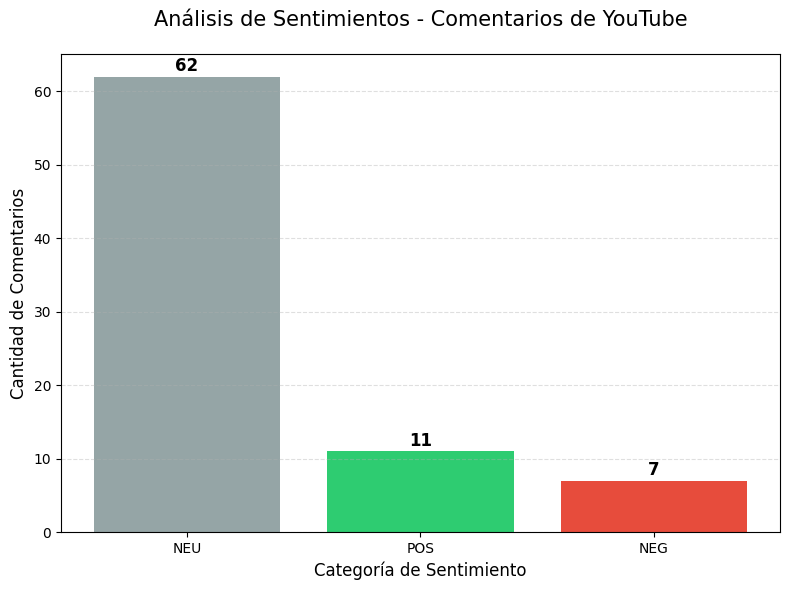

✅ Gráfica generada correctamente.


In [ ]:
plt.figure(figsize=(8, 6))

paleta_colores = {'POS': '#2ecc71', 'NEG': '#e74c3c', 'NEU': '#95a5a6'}
barras = plt.bar(conteo.index, conteo.values,
                 color=[paleta_colores.get(x, '#3498db') for x in conteo.index])

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.2,
             f'{int(altura)}', ha='center', va='bottom', fontsize=12, fontweight='bold')


plt.title('Análisis de Sentimientos - Comentarios de YouTube', fontsize=15, pad=20)
plt.xlabel('Categoría de Sentimiento', fontsize=12)
plt.ylabel('Cantidad de Comentarios', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()

print("✅ Gráfica generada correctamente.")

## **Generación del Informe Final e Interpretación de Resultados**


In [ ]:
total = len(tabla_resultados)
porcentajes = (conteo / total * 100).round(1)


sentimiento_predominante = conteo.idxmax()
porcentaje_predominante = porcentajes[sentimiento_predominante]

print("\n" + "═" * 55)
print("📌 INFORME DE ANÁLISIS DE SENTIMIENTOS")
print("═" * 55)
print(f"🔹 Total de comentarios analizados: {total}\n")

for sentimiento, cantidad in conteo.items():
    print(f"   • {sentimiento}: {cantidad} comentarios ({porcentajes[sentimiento]}%)")

print(f"\n🔹 Sentimiento predominante: {sentimiento_predominante} ({porcentaje_predominante}%)")


if sentimiento_predominante == 'POS':
    print("\n💡 Interpretación: La mayoría de las opiniones son positivas. El contenido genera una respuesta favorable en la audiencia.")
elif sentimiento_predominante == 'NEG':
    print("\n💡 Interpretación: Predominan las críticas o comentarios negativos. Sería recomendable revisar las posibles causas de esta percepción.")
else:
    print("\n💡 Interpretación: Los comentarios son principalmente neutrales o mixtos. No hay una tendencia clara hacia lo positivo o negativo.")

print("═" * 55)


═══════════════════════════════════════════════════════
📌 INFORME DE ANÁLISIS DE SENTIMIENTOS
═══════════════════════════════════════════════════════
🔹 Total de comentarios analizados: 80

   • NEU: 62 comentarios (77.5%)
   • POS: 11 comentarios (13.8%)
   • NEG: 7 comentarios (8.8%)

🔹 Sentimiento predominante: NEU (77.5%)

💡 Interpretación: Los comentarios son principalmente neutrales o mixtos. No hay una tendencia clara hacia lo positivo o negativo.
═══════════════════════════════════════════════════════


# Imagen de los comentarios previos

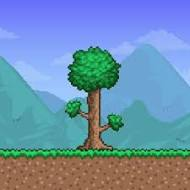